# Cyber Scout — stage 1: is this SMS suspicious?

Ports the LightGBM + Bayesian-optimisation + SHAP skeleton from `analysis_final.ipynb`
onto the SMS problem described in `Cyber-Scout-Analysis-Plan.docx`.

The slow work (dataset build, embeddings, 50-fit Bayesian search per arm) lives in
scripts so it is not repeated on every notebook run:

| step | script | output |
|---|---|---|
| merge + label + group the 5 sources | `merge_datasets.py` | `combined_sms_dataset.csv` |
| scam-type mapping | `scam_types.py` | `scam_type` column |
| engineered features | `features.py` | `features.parquet` |
| sentence embeddings | `embed.py` | `embeddings_*.npy` |
| train + score every arm | `run_arms.py` | `results/arm_metrics.csv` |

Run `python run_arms.py` before this notebook.

In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import features as F
import modeling as M

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
RESULTS = "results"

## 1. Data and splits

Two rules govern the split, both of them load-bearing:

* **No `dup_group` straddles a split.** Smishing is templated — the same scam is resent
  with a fresh tracking URL — so a row-level split puts near-identical messages on both
  sides and inflates every score.
* **Validation and test contain only clean-labelled rows.** The `Smishing_Dataset`
  source was labelled by keyword matching, so scoring against it would measure agreement
  with a keyword rule rather than detection of smishing. Those rows still train.

In [2]:
df = M.load()
split = M.make_splits(df)
_ = M.describe_splits(df, split)

label    ham  smishing  spam   rows  positives  positive_rate
split                                                        
test    9766       341    13  10120        354         0.0350
train  39357     22347  6598  68302      28945         0.4238
val     9766       342    12  10120        354         0.0350

test positives: 354 -- recall CI on this set is about +/- 2.3 points at 95% recall


The positive rate gap (~42% train vs ~3.5% val/test) is a consequence of the second rule:
the clean sources are overwhelmingly NUS ham, so only ~1,750 clean *suspicious* messages
exist in the whole corpus. Read the consequences off `describe_splits`:

* recall on test rests on ~354 positives, so quote its bootstrap interval, not the point;
* precision and accuracy shift with prevalence and are **not** comparable across splits;
  recall, specificity and AUC are within-class and are unaffected.

A ~3.5% positive rate is, if anything, closer to real inbox prevalence than 42% would be.

## 2. Arm comparison on one common test set

| arm | what it is |
|---|---|
| `keyword` | rule-based floor — the kind of rule that produced `Smishing_Dataset`'s labels |
| `tfidf` | TF-IDF (fitted on train only) + LightGBM |
| `minilm` | all-MiniLM-L6-v2 embeddings + LightGBM |
| `qwen` | Qwen3-Embedding-0.6B + LightGBM |
| `qwen_feat` | Qwen + the engineered features from `features.py` |
| `ann` | MLP on Qwen embeddings, tuned with Optuna |
| `qwen_feat_clean` | `qwen_feat` retrained **without** the keyword-labelled rows — the leakage ablation |

Every arm picks its threshold on validation as the highest one still clearing 95% recall,
then that threshold is applied unchanged to test.

In [3]:
m = pd.read_csv(os.path.join(RESULTS, "arm_metrics.csv"))
test = m[m.split == "test"].set_index("arm")
cols = ["auc", "ap", "recall", "recall_lo", "recall_hi", "specificity", "precision", "threshold"]
test[[c for c in cols if c in test.columns]].round(4)

,auc,ap,recall,recall_lo,recall_hi,specificity,precision,threshold
arm,,,,,,,,
keyword,0.8508,0.4914,1.0000,1.0000,1.0000,0.0000,0.0350,0.0000
tfidf,0.9893,0.9317,0.9463,0.9217,0.9680,0.9824,0.6607,0.4969
minilm,0.9902,0.8889,0.9548,0.9308,0.9752,0.9529,0.4236,0.1605
qwen,0.9946,0.9271,0.9379,0.9118,0.9628,0.9848,0.6917,0.3840
qwen_feat,0.9959,0.9653,0.9379,0.9109,0.9643,0.9962,0.8997,0.6396
ann,0.9961,0.9494,0.8955,0.8594,0.9284,0.9953,0.8733,0.9125
qwen_feat_clean,0.9963,0.9678,0.9294,0.9003,0.9555,0.9983,0.9509,0.4611


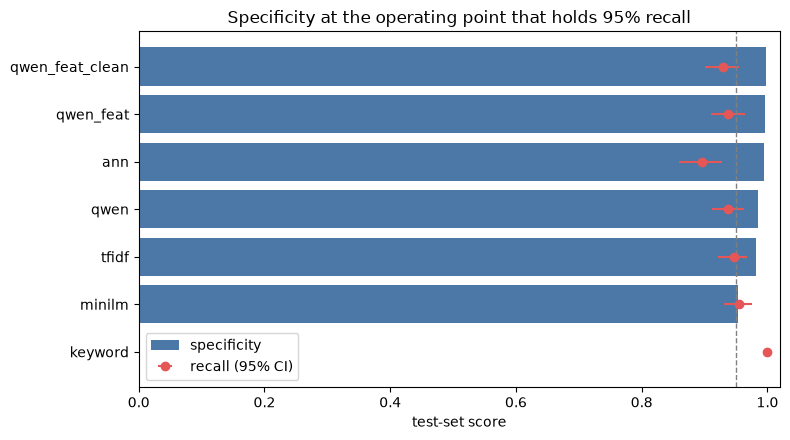

In [4]:
# Did each arm actually hold the 95% recall target it was tuned for?
fig, ax = plt.subplots(figsize=(8, 4.5))
order = test.sort_values("specificity").index
y = np.arange(len(order))
ax.barh(y, test.loc[order, "specificity"], color="#4C78A8", label="specificity")
ax.errorbar(test.loc[order, "recall"], y,
            xerr=[test.loc[order, "recall"] - test.loc[order, "recall_lo"],
                  test.loc[order, "recall_hi"] - test.loc[order, "recall"]],
            fmt="o", color="#E45756", label="recall (95% CI)")
ax.axvline(0.95, ls="--", c="grey", lw=1)
ax.set_yticks(y, order); ax.set_xlim(0, 1.02)
ax.set_xlabel("test-set score"); ax.legend(loc="lower left")
ax.set_title("Specificity at the operating point that holds 95% recall")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "arm_comparison.png"), dpi=200)
plt.show()

### The leakage check

`qwen_feat` trains on 36k keyword-labelled rows; `qwen_feat_clean` does not. If the gap
between them on the clean test set is large, the model learned the keyword labeller
rather than smishing, and the keyword rows should be dropped.

In [5]:
NUM = ["auc", "recall", "recall_lo", "recall_hi", "specificity", "precision", "fn", "fp"]
pair = test.loc[[a for a in ("qwen_feat", "qwen_feat_clean") if a in test.index], NUM]
display(pair.round(4))
if len(pair) == 2:
    # subtract only the numeric columns -- the frame also carries `split`, a string
    d = pair.loc["qwen_feat"] - pair.loc["qwen_feat_clean"]
    print(f"Dropping the 36,484 keyword-labelled training rows moves "
          f"AUC by {-d['auc']:+.4f} and specificity by {-d['specificity']:+.4f};")
    print(f"missed scams {int(pair.loc['qwen_feat','fn'])} -> {int(pair.loc['qwen_feat_clean','fn'])} of 354, "
          f"false alarms {int(pair.loc['qwen_feat','fp'])} -> {int(pair.loc['qwen_feat_clean','fp'])} of 9,766.")
    print("The recall intervals overlap almost entirely, so the keyword rows are not")
    print("buying accuracy -- they are only making training 3.5x slower.")

,auc,recall,recall_lo,recall_hi,specificity,precision,fn,fp
arm,,,,,,,,
qwen_feat,0.9959,0.9379,0.9109,0.9643,0.9962,0.8997,22,37
qwen_feat_clean,0.9963,0.9294,0.9003,0.9555,0.9983,0.9509,25,17


Dropping the 36,484 keyword-labelled training rows moves AUC by +0.0005 and specificity by +0.0020;
missed scams 22 -> 25 of 354, false alarms 37 -> 17 of 9,766.
The recall intervals overlap almost entirely, so the keyword rows are not
buying accuracy -- they are only making training 3.5x slower.


## 3. What the model keys on (SHAP)

`analysis_final.ipynb` runs SHAP over raw model inputs. Here 1,024 of those are embedding
dimensions with no human meaning, so plotting them individually says nothing. Instead the
1,024 embedding dimensions are collapsed into a single contribution and the 29 engineered
features — which do have names — are shown individually.

In [6]:
import shap

with open(os.path.join(RESULTS, "model_qwen_feat.pkl"), "rb") as fh:
    bundle = pickle.load(fh)
clf, names = bundle["model"], bundle["feature_names"]

import run_arms
ids = df["id"].to_numpy()
X, _ = run_arms.feature_matrix("qwen_feat", df, ids)
te = (split == "test").values
Xte = X[te]

explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(Xte)
if isinstance(sv, list):
    sv = sv[1]
print("shap values:", sv.shape)

C:\Users\guntu\miniconda3\envs\cyberscout\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap values: (10120, 1053)


C:\Users\guntu\miniconda3\envs\cyberscout\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


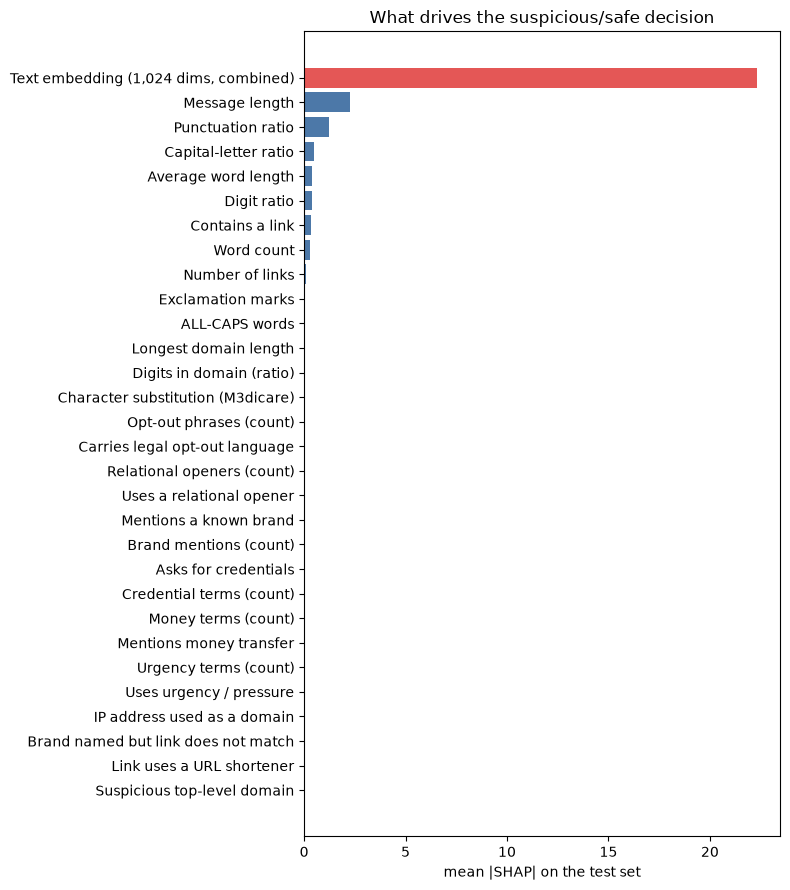

In [7]:
n_emb = len(names) - len(F.FEATURE_NAMES)
emb_total = np.abs(sv[:, :n_emb]).sum(axis=1)          # all 1024 dims as one contribution
eng = np.abs(sv[:, n_emb:]).mean(axis=0)

imp = pd.Series(eng, index=[F.FEATURE_LABELS.get(n, n) for n in F.FEATURE_NAMES])
imp["Text embedding (1,024 dims, combined)"] = emb_total.mean()
imp = imp.sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#E45756" if "embedding" in i else "#4C78A8" for i in imp.index]
ax.barh(imp.index, imp.values, color=colors)
ax.set_xlabel("mean |SHAP| on the test set")
ax.set_title("What drives the suspicious/safe decision")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "shap_importance.png"), dpi=200)
plt.show()

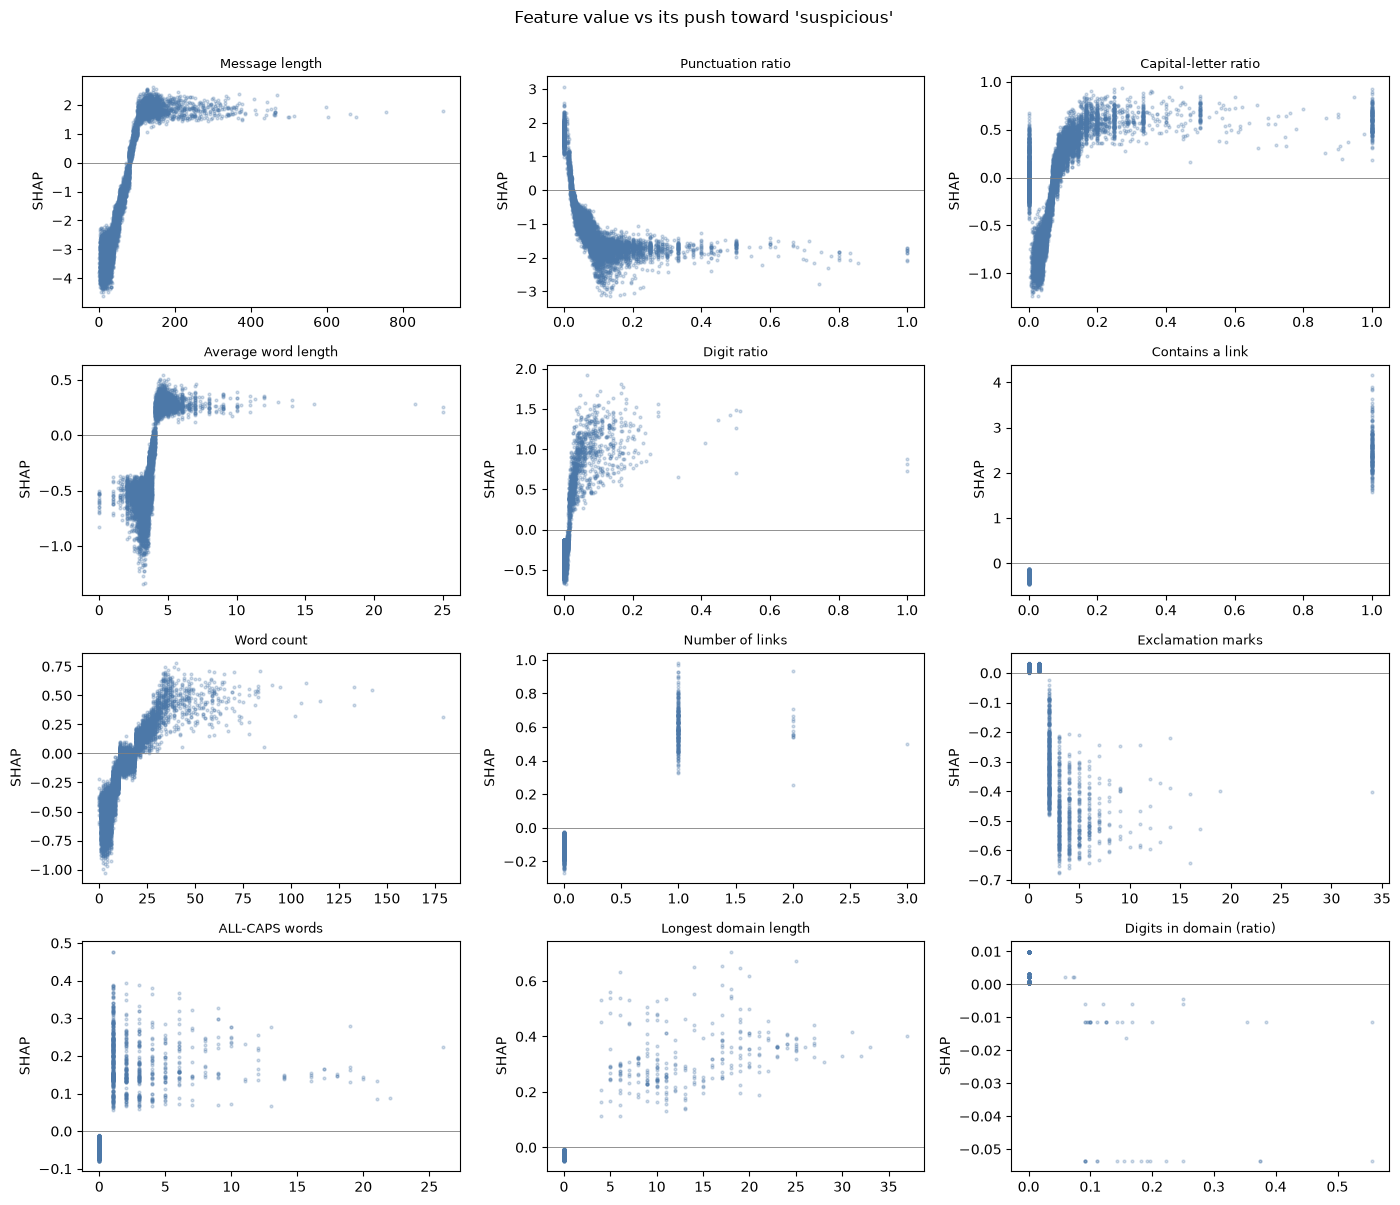

In [8]:
# Signed effect of the named features: does having a link push toward suspicious?
top = imp.drop("Text embedding (1,024 dims, combined)").tail(12).index[::-1]
label_to_col = {F.FEATURE_LABELS.get(n, n): i for i, n in enumerate(F.FEATURE_NAMES)}
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
for ax, lab in zip(axes.ravel(), top):
    j = n_emb + label_to_col[lab]
    ax.scatter(Xte[:, j], sv[:, j], s=4, alpha=.25, c="#4C78A8")
    ax.axhline(0, c="grey", lw=.6)
    ax.set_title(lab, fontsize=9); ax.set_xlabel(""); ax.set_ylabel("SHAP")
plt.suptitle("Feature value vs its push toward 'suspicious'", y=1.0)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "shap_dependence.png"), dpi=200)
plt.show()

## 4. Choosing the operating point

The plan sets the target as catching at least 95% of scams. That fixes recall and lets
specificity fall where it may — every point of specificity given up is a safe message
shown to an older adult as a warning, so the curve below is the real design decision.

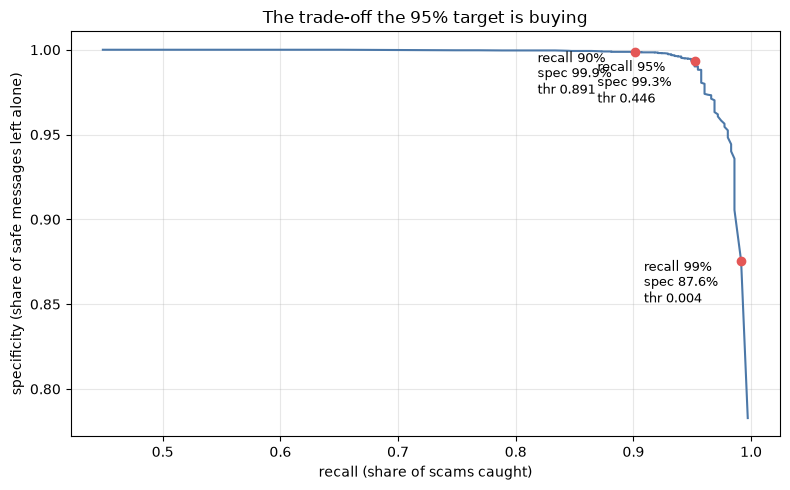

at 90% recall: threshold 0.891, specificity 0.999 -> 1 false alarms per 1,000 safe messages
at 95% recall: threshold 0.446, specificity 0.993 -> 7 false alarms per 1,000 safe messages
at 99% recall: threshold 0.004, specificity 0.876 -> 124 false alarms per 1,000 safe messages


In [9]:
p_test = np.load(os.path.join(RESULTS, "probs_qwen_feat_test.npy"))
y_test = df.loc[te, "y"].to_numpy()

grid = np.linspace(0.001, 0.999, 400)
rows = [M.binary_metrics(y_test, p_test, t) for t in grid]
curve = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve.recall, curve.specificity, c="#4C78A8")
for target in (0.90, 0.95, 0.99):
    ok = curve[curve.recall >= target]
    if len(ok):
        best = ok.iloc[ok.specificity.argmax()]
        ax.scatter([best.recall], [best.specificity], zorder=5, c="#E45756")
        ax.annotate(f"recall {target:.0%}\nspec {best.specificity:.1%}\nthr {best.threshold:.3f}",
                    (best.recall, best.specificity), textcoords="offset points",
                    xytext=(-70, -30), fontsize=9)
ax.set_xlabel("recall (share of scams caught)")
ax.set_ylabel("specificity (share of safe messages left alone)")
ax.set_title("The trade-off the 95% target is buying")
ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "operating_point.png"), dpi=200)
plt.show()

for target in (0.90, 0.95, 0.99):
    ok = curve[curve.recall >= target]
    if len(ok):
        b = ok.iloc[ok.specificity.argmax()]
        fp_per_1000 = (1 - b.specificity) * 1000
        print(f"at {target:.0%} recall: threshold {b.threshold:.3f}, "
              f"specificity {b.specificity:.3f} -> {fp_per_1000:.0f} false alarms "
              f"per 1,000 safe messages")

### The 95% target does not survive the trip from validation to test

The threshold is fitted on validation to hold exactly 95% recall, and test then comes in
*below* it — in the smoke run, 92.9%. That is not a bug: with ~354 positives on each
side, the threshold that gives 95% on one sample gives 95% ± 2 on another, and picking
the tightest threshold that just clears the bar means the error lands below it about half
the time.

If the 95% floor is a real requirement rather than a reporting target, tune validation to
a higher number and let test land on 95%. The curve below shows what val target is needed.

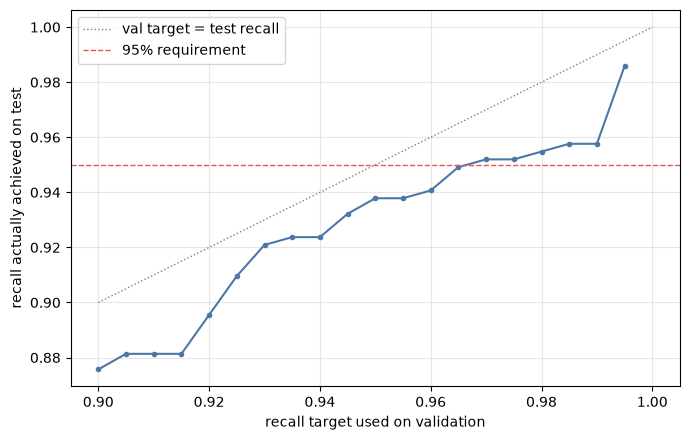

to land at 95% recall on test, tune validation to 97.0% -- costing specificity 0.991


In [10]:
# clf and X come from the SHAP cell above
va = (split == "val").values
p_val = clf.predict_proba(X[va])[:, 1]
y_val = df.loc[va, "y"].to_numpy()

rows = []
for target in np.arange(0.90, 0.996, 0.005):
    thr = M.pick_threshold(y_val, p_val, target)
    rows.append({"val_target": target,
                 "test_recall": M.binary_metrics(y_test, p_test, thr)["recall"],
                 "test_specificity": M.binary_metrics(y_test, p_test, thr)["specificity"]})
margin = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(margin.val_target, margin.test_recall, marker="o", ms=3, c="#4C78A8")
ax.plot([0.90, 1.0], [0.90, 1.0], ls=":", c="grey", lw=1, label="val target = test recall")
ax.axhline(0.95, ls="--", c="#E45756", lw=1, label="95% requirement")
ax.set_xlabel("recall target used on validation")
ax.set_ylabel("recall actually achieved on test")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "recall_margin.png"), dpi=200)
plt.show()

need = margin[margin.test_recall >= 0.95]
if len(need):
    r = need.iloc[0]
    print(f"to land at 95% recall on test, tune validation to {r.val_target:.1%} "
          f"-- costing specificity {r.test_specificity:.3f}")

## 5. Known limits

* **Test rests on ~354 suspicious messages.** The clean sources are mostly NUS ham. The
  fix is more clean positives — SmishTank (~1,000 current scams) and the 300+ collected
  messages named in the plan, neither of which is in the project yet.
* **The data is 2011–2022.** Nothing here has seen a 2026 scam. The collected set was
  meant to be the held-out realistic test and does not exist yet, so treat every number
  as an upper bound on current-day performance.
* **`scam_type` covers 1,055 messages and 10 of 13 types.** Family emergency, charity and
  Medicare/health have no examples at all; utility shutoff has one. Stage 2 cannot be
  evaluated on those until they are hand-labelled.
* **Opt-out language did not behave as the plan predicted.** The plan expects `Reply STOP`
  to mark legitimate marketing; measured, it fires more often on smishing (3.2%) than on
  advertisement spam (0.4%), because scammers mimic it. It is still a useful feature — it
  just points the other way.